# Laser Diffraction Plots

This program reads data from Malvern Spraytec and plots it.

    @author Sanjiv Gunasekera <sanjiv.gunasekera@monash.edu> 
    @version 0.0.1
    @date 3/12/2025
    
    Reproduced using Raman Spectroscopy plotting script developed by Daniel Duke <daniel.duke@monash.edu>.

    Multiphase Flow Laboratory
    Monash University, Australia


#### Libraries
os - for filepaths to be independant of operating system \
dataclass - to replicate matlab struct \
scipy.io - to load .mat matlab files \
panda - openpyxl dependency needs to be installed to load excel data. Jinja2 needed to be installed for table styles. \
pywt - to load wavelet functions \
CoolProp - for thermophysical properties similar to REFPROP but free. \
miepython - to use mie theory

In [1]:
import numpy as np
import datetime, time, os
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from dataclasses import dataclass
import scipy.io
from scipy import signal
import matplotlib
# from matplotlib.ticker import AutoMinorLocator
import pandas as pd
import miepython as mie

# import pywt
# import CoolProp.CoolProp as CP

# %matplotlib widget
# %matplotlib qt5
%matplotlib inline

#### Figure formatting for journal papers

In [2]:
matplotlib.rcParams['lines.antialiased']          = True
matplotlib.rcParams['text.usetex']                = False
matplotlib.rcParams['font.size']                  = 10
# matplotlib.rcParams['font.family']                = 'serif'
matplotlib.rcParams['font.family']                = 'arial'
matplotlib.rcParams['xtick.major.pad']            = 8
matplotlib.rcParams['ytick.major.pad']            = 4
matplotlib.rcParams['image.interpolation']        = 'gaussian'
matplotlib.rcParams['image.origin']               = 'lower'
matplotlib.rcParams['ps.papersize']               = 'a4'
matplotlib.rcParams['ps.usedistiller']            = 'xpdf'
matplotlib.rcParams['legend.fontsize']            = 12
matplotlib.rcParams['xtick.major.pad']=12
matplotlib.rcParams['ytick.major.pad']=12
matplotlib.rcParams["figure.dpi"] = 200
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams["savefig.bbox"] = 'tight'
matplotlib.rcParams["savefig.pad_inches"] = 0.05
matplotlib.rcParams['figure.max_open_warning'] = 50
figsize = [3.37 ,3.37 ] # 1 column figure
matplotlib.rcParams['figure.figsize'] = figsize # 1 column figure
# matplotlib.rcParams['figure.figsize'] = [6.69 ,3.37 ] # 2 column figure

### User Input

In [3]:
stable_wind_time = 0.5 # seconds
transmission_thresh = 80 # percent, threshold to consider experiment transmission
cv_thresh = 0.05 # percent/100, coefficient of variation threshold

HeNe_lam = 632.8 # nm, Wavelength of the Malvern Spraytec
h2o_l_m = 1.33 # , Refractive index of water
h2o_g_m = 1.00 # , Refractive index of water vapour

nz_d = 1.56 # mm, Using this to calculate number density.  
opt_wind_d = 10 # mm, Optical window diameter or Laser beam diameter
liq_dom_l = 36 # mm, Length of the liquid domain, removed 1mm on each side for the windows

## Functions
1. Load and clean Malvern data \
<br>
2. Find stable experiment window \
<br>
3. Convert volume percentage based distribution to number distribution \
<br>

In [4]:
def readMalvernSpraytecFile(filename):
    # TXT file is a tab separated array with time snapshots in the columns and diameters in the rows.
    # Read this into a Pandas dataframe, with the headers as the data.

    with open(filename, 'r', encoding="cp1252") as inFile:
        lines = inFile.readlines()

        # Splitting the header lines using tab delimiter
        headerField = lines[0].split('\t')
        headerField = [p.strip() for p in headerField] # removing the \n from the last header

        # same as above
        data_raw = []
        for line in lines[1:]:
            data_temp = line.split('\t')
            data_raw.append([p.strip() for p in data_temp])

    
    df = pd.DataFrame(data_raw, columns=headerField)

    # Converting column headers with numerics for easy plotting later
    col_headers = df.columns.to_list()
    for i in range(len(col_headers)):
        try:
            col_headers[i] = pd.to_numeric(df.columns[i])
            # print(col_headers[i])
        except:
            # print('exception at index:', i)
            pass
    df.columns = col_headers

    # Converting data to appropriate types
    # date time conversions
    df["*D"] = pd.to_datetime(df["*D"], format='%d/%m/%Y')
    df["T"] = pd.to_datetime(df["T"], format='%H:%M')
    # numeric conversions - currently all columns except first two rows have numeric data. This line needs to be made more robust.
    df.iloc[:, 2:] = df.iloc[:, 2:].apply(pd.to_numeric, errors='coerce')

    # Finding where particle distribution diameters start
    for i, col in enumerate(df.columns):
        if not pd.isna(pd.to_numeric(col, errors='coerce')):
            first_numeric_idx = i
            break
    # Setting NaN to match transmission
    df.iloc[df["Trans(Value)"].isna().values, first_numeric_idx:] = np.nan

    # Calculate bin middle values
    col_headers = df.columns.to_list()
    bin_edges = np.array(col_headers[first_numeric_idx:])
    bin_mid = 0.5 * (np.array(col_headers[first_numeric_idx+1:])  + np.array(col_headers[first_numeric_idx:-1]))
    
    # Replace columns with mid values and remove additional column
    col_headers[first_numeric_idx+1:] = bin_mid
    df.columns = col_headers
    df.drop(df.columns[first_numeric_idx], axis=1, inplace=True)

    # Calculating rough sample frequency
    sample_freq = np.round(np.mean(1/np.diff(df.loc[:, "Time (relative)"])))

    return df, sample_freq, bin_edges

In [5]:
# Input Transmission signal instead of Trans(Values)

def stableExperimentWindow(transmission_signal, stable_wind_ind, transmission_thresh, cv_thresh):

    # Use moving mean
    transmission_movmean_sig = pd.Series(transmission_signal).rolling(window=stable_wind_ind, center=True).mean().to_numpy()

    # Remove time when cavitation/spray is not present
    transmission_movmean_sig[transmission_movmean_sig>transmission_thresh] = np.nan

    # Coefficient of variation of transmission signal
    transmission_movmean_cv = pd.Series(transmission_movmean_sig).rolling(window=stable_wind_ind, center=True).var().to_numpy()/transmission_movmean_sig
        
    # CV below threshold
    low_cv_bool = transmission_movmean_cv < cv_thresh
    low_cv_wind_inds = np.where(np.diff(low_cv_bool) == 1)[0]

    # Output
    exp_start_ind = low_cv_wind_inds[pd.Series(np.diff(low_cv_wind_inds)).idxmax()]
    exp_end_ind = low_cv_wind_inds[pd.Series(np.diff(low_cv_wind_inds)).idxmax()+1]

    print([exp_start_ind, exp_end_ind])

    return exp_start_ind, exp_end_ind

In [6]:
def volDist2numDist(df_v):
    
    # Finding where particle distribution diameters start
    for i, col in enumerate(df_v.columns):
        if not pd.isna(pd.to_numeric(col, errors='coerce')):
            first_numeric_idx = i
            break

    # Calculating equivalent volume of of diameters 
    vol_bin_mids = df_v.columns[first_numeric_idx:].astype(float).to_numpy()**3

    number_raw = df_v.iloc[:, first_numeric_idx:].astype(float).to_numpy()
    number_raw = number_raw / vol_bin_mids

    number_sum = np.nansum(number_raw, axis=1)
    number_sum = number_sum[:, np.newaxis]
    number_percent = 100 * number_raw / np.repeat(number_sum, number_raw.shape[1], axis=1)

    return number_percent

## Main body of code

#### File locations

In [7]:
#inDir = r"\\cephfs-smb-rds.erc.monash.edu.au\pharma-sprays\SanjivGunasekera\Experiment\gas_release_img\sensor_data\malvern_data"
# inDir = r"G:\My Drive\B. Experiment\B.5. Cavitation\sensor_logging_runs\malvern_data"
inDir = '/Users/dduke/Library/CloudStorage/GoogleDrive-daniel.duke@monash.edu/My Drive/Conferences/2026 AFMC/BubblesPaper/Malvern Data Cavitation'

run1_n_file = "run01_20251127_number_percentage.txt"
run1_v_file = "run01_20251127_volume_percentage.txt"

run4_n_file = "run04_20251127_number_percentage.txt"
run4_v_file = "run04_20251127_volume_percentage.txt"

df_run1_n, run1_freq_n, bin_edges1_n = readMalvernSpraytecFile(os.path.join(inDir, run1_n_file))
df_run1_v, run1_freq_v, bin_edges1_v = readMalvernSpraytecFile(os.path.join(inDir, run1_v_file))
df_run4_n, run4_freq_n, bin_edges4_n = readMalvernSpraytecFile(os.path.join(inDir, run4_n_file))
df_run4_v, run4_freq_v, bin_edges4_v = readMalvernSpraytecFile(os.path.join(inDir, run4_v_file))

df_run1_n.iloc[:,16:] = volDist2numDist(df_run1_v)
df_run4_n.iloc[:,16:] = volDist2numDist(df_run4_v)


#### Find stable region
Using the transmission data to determine the period where the cavitation/spray is consistent.

[np.int64(28791), np.int64(100471)]
[np.int64(28791), np.int64(100471)]
[np.int64(34253), np.int64(145001)]
[np.int64(34253), np.int64(145001)]


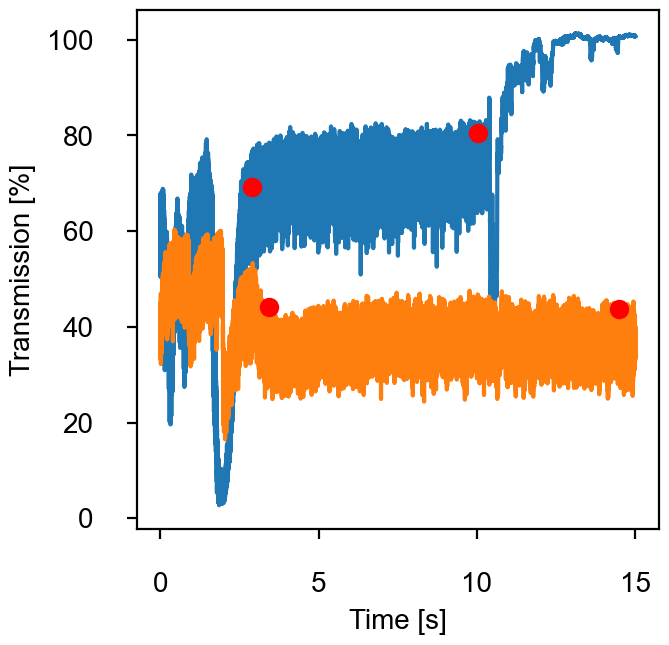

In [8]:
# Need to calculate the stable_wind_ind for every run in case different sample frequencies were used
stable_wind_ind = int(stable_wind_time * run1_freq_n)
run1_n_start, run1_n_end = stableExperimentWindow(df_run1_n["Transmission"], stable_wind_ind, transmission_thresh, cv_thresh)
run1_v_start, run1_v_end = stableExperimentWindow(df_run1_v["Transmission"], stable_wind_ind, transmission_thresh, cv_thresh)
run4_n_start, run4_n_end = stableExperimentWindow(df_run4_n["Transmission"], stable_wind_ind, transmission_thresh, cv_thresh)
run4_v_start, run4_v_end = stableExperimentWindow(df_run4_v["Transmission"], stable_wind_ind, transmission_thresh, cv_thresh)


fig, ax = plt.subplots()

# Check if the experiment windows are calculated correctly
ax.plot(df_run1_n["Time (relative)"], df_run1_n["Transmission"])
ax.plot(df_run4_n["Time (relative)"], df_run4_n["Transmission"])
ax.plot(df_run1_v.loc[run1_n_start, "Time (relative)"], df_run1_n.loc[run1_n_start, "Transmission"], 'ro')
ax.plot(df_run1_v.loc[run1_n_end, "Time (relative)"], df_run1_n.loc[run1_n_end, "Transmission"], 'ro')
ax.plot(df_run1_v.loc[run4_n_start, "Time (relative)"], df_run4_n.loc[run1_n_start, "Transmission"], 'ro')
ax.plot(df_run1_v.loc[run4_n_end, "Time (relative)"], df_run4_n.loc[run1_n_end, "Transmission"], 'ro')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Transmission [%]')

# ax.plot(df_run1_v["Time (relative)"], df_run1_v["Transmission"])
# ax.plot(df_run4_v["Time (relative)"], df_run4_v["Transmission"])

# ax.plot(df_run1_v["Time (relative)"], df_run1_v["Cv(%)"])
# ax.plot(df_run4_v["Time (relative)"], df_run4_v["Cv(%)"])

plt.show()


#### Calculate extinction

Multiple papers (like [Dannigkeit et al 2012](https://ilasseurope.org/ICLASS/iclass2012_Heidelberg/Contributions/Paper-pdfs/Contribution1179_b.pdf), [Wellander et al 2011](http://dx.doi.org/10.1088/0957-0233/22/12/125303),  [Grosshans et al 2015](http://dx.doi.org/10.1016/j.ijmultiphaseflow.2015.01.009) and a few others) have described a method to calculate the absolute particle density using the transmission and particle distribution data. The miepython documentation also has some of the working scattered in different sections. 

$$ 
\sigma_{ext} = \pi r^2 Q_{ext}
$$
$$
Q_{ext}(r, \lambda, m)~\leftarrow~\text{using miepython library}
$$

For cavitation example, the vapour bubbles ($m_g$ = 1.00) are within the water ($m_l$ = 1.33) so the effective refractive index used is $m_g/m_l$. Even when swapped the impact is significant for bubbles smaller than 10 microns. Beyond 10 microns, the factor converges to '2'. Ideally, the complex refractive index value should be used. The imaginary component of the refractive index (tied to attenuation) has been ignored as it is close to zero at the wavelength of concern (or most visible wavelengths). 

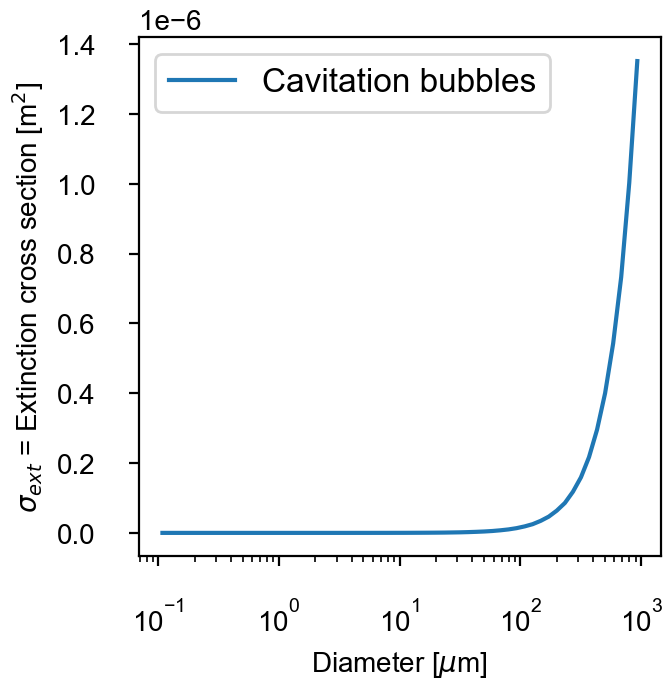

In [9]:
for i, col in enumerate(df_run1_v.columns):
    if isinstance(col, float):
        start_idx = i
        break

# x = 2 * np.pi * r / (HeNe_lam * 0.001)
x = np.pi * df_run1_v.columns[start_idx:] / (HeNe_lam * 0.001)
m = h2o_g_m / h2o_l_m
qext, qsca, qback, g = mie.efficiencies_mx(m, x)
qext_alt, qsca, qback, g = mie.efficiencies_mx(1/m, x)

sigext = np.pi * (df_run1_v.columns[start_idx:] * 10**-6)**2 * 0.25 * qext

# Visualising the effect of refractive index on extinction efficiency
# fig, ax = plt.subplots()
# ax.plot(df_run1_v.columns[start_idx:], qext, label='m_g / m_l')
# ax.plot(df_run1_v.columns[start_idx:], qext_alt, label='m_l / m_g')
# ax.legend(loc='lower right')
# ax.set_xscale('log')
# ax.set_xlabel('Diameter [$\mu$m]')
# ax.set_ylabel('Q$_{ext}$ = Extinction efficiency factor')
# plt.show()

# Visualising the variation of the extinction cross section 
fig, ax = plt.subplots()
ax.plot(df_run1_v.columns[start_idx:], sigext, label='Cavitation bubbles')
ax.legend(loc='upper left')
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel(r'Diameter [$\mu$m]')
# ax.set_ylabel(r'$\sigma_{ext}$ = Extinction cross section [$\mu$m$^2$]')
ax.set_ylabel(r'$\sigma_{ext}$ = Extinction cross section [m$^2$]')
plt.show()

#### Calculating number density 

The following equations have been altered from the aforementioned papers to suit the variables calculated from the Malvern Spraytec output

$$
-ln(T) = N \cdot \int_{0}^{\infty} n(D) \sigma_{ext}(D) \,dD\cdot L
$$
T is the transmission (as a ratio not percentage like the Malvern output), L is the path length through the domain. L should be the path length through the cavitation/spray thickness and not the whole domain. L represents the thickness of the region with extinction of $\sigma_{ext}$. 

$$
n(D) = \frac{f_v(D)/v(D)}{\int_{0}^{\infty} f_v(D)/v(D) \,dD}
$$
$n(D)$ is the relative number distribution which already comes out as a ratio. 

Because L is going to be an approximate value, the average number distribution across the stable experimentation time will be used for the calculation. Because the average number density is used, the calculation is continued later on in this script.

#### Calculating the frequency of the temporal fluctuations



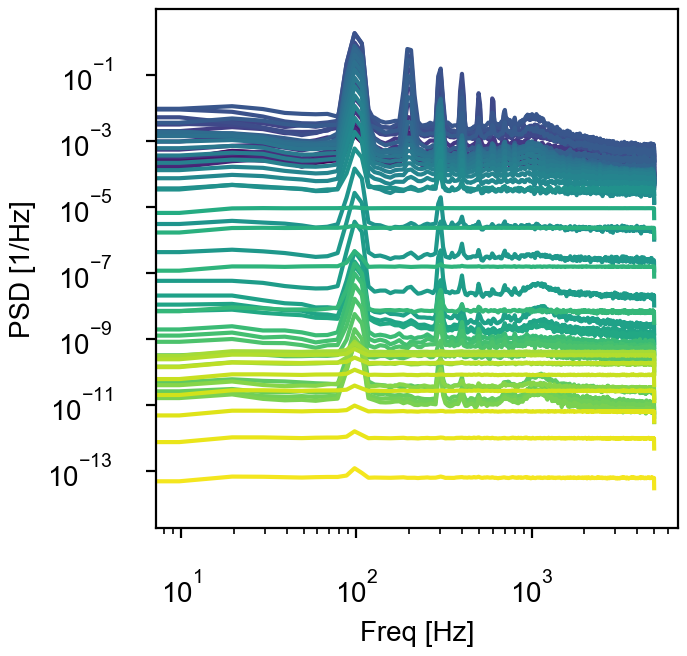

In [10]:
# %matplotlib widget
%matplotlib inline

from matplotlib.colors import LogNorm

fs = 10*1000 # Hz, sample frequency
col_num = 56
# test_data = np.array(df_run1_v.iloc[run1_v_start:run1_v_end,col_num].to_list())
# test_data = np.array(df_run4_v.iloc[run4_v_start:run4_v_end,col_num].to_list())
# test_data[np.isnan(test_data)] = 0

# f, Pxx_den = signal.welch(test_data, fs, nperseg=1024)
# f, Pxx_den = signal.welch(df_run4_v.iloc[run4_v_start:run4_v_end,16], fs, nperseg=1024)
# plt.semilogy(f, Pxx_den)
# plt.semilogy(f * nz_d / 21.82, Pxx_den)
# plt.loglog(f * nz_d * 0.001 / 21.82, Pxx_den)
# plt.ylim([0.5e-3, 1])
# plt.xlabel('frequency [Hz]')
# plt.xlabel('Strouhal number = fD/U [-]')
# plt.ylabel('PSD [V**2/Hz]')
# plt.show()
# plt.close('all')

test_data = df_run1_n.iloc[run1_n_start:run1_n_end,16:].to_numpy().tolist()
# test_data = df_run1_v.iloc[run1_v_start:run1_v_end,16:].to_numpy().tolist()
# test_data = df_run4_n.iloc[run4_n_start:run4_n_end,16:].to_numpy().tolist()
# test_data = df_run4_v.iloc[run4_v_start:run4_v_end,16:].to_numpy().tolist()
test_data = np.nan_to_num(test_data, nan=0.0)

f, Pxx_den = signal.welch(test_data, fs, nperseg=1024, axis=0, detrend='linear')

for i, vals in enumerate(Pxx_den.T):
    #plt.loglog(f * nz_d * 0.001 / 21.82, vals, color=plt.cm.viridis(i / Pxx_den.shape[1]))
    plt.loglog(f , vals, color=plt.cm.viridis(i / Pxx_den.shape[1]))

# plt.loglog(f * nz_d * 0.001 / 21.82, Pxx_den);
# plt.show()

# xvals, yvals = np.meshgrid(df_run1_n.columns[16:], f * nz_d * 0.001 / 21.82)
# xvals, yvals = np.meshgrid( f, df_run1_n.columns[16:])

# plt.imshow(Pxx_den, origin='lower', aspect='auto')
# plt.contourf(Pxx_den, levels=30)
# plt.contourf(xvals, yvals, Pxx_den, norm=LogNorm())

# plt.xscale('log')
# plt.yscale('log')
# plt.colorbar()

#plt.xlabel('Strouhal number = fD/U [-]')
plt.xlabel('Freq [Hz]')
plt.ylabel('PSD [1/Hz]')
# plt.clim(0.00001, 0.1)
plt.show()

# plt.plot(df_run1_v.iloc[run1_v_start:run1_v_end,70].to_list())
# plt.show()

#### Yunpeng determined that the fluctuations were caused by the overhead lighting and should be averaged out!

----

## Produce results

Plot the raw data, then plot the data all added up with the background removed.

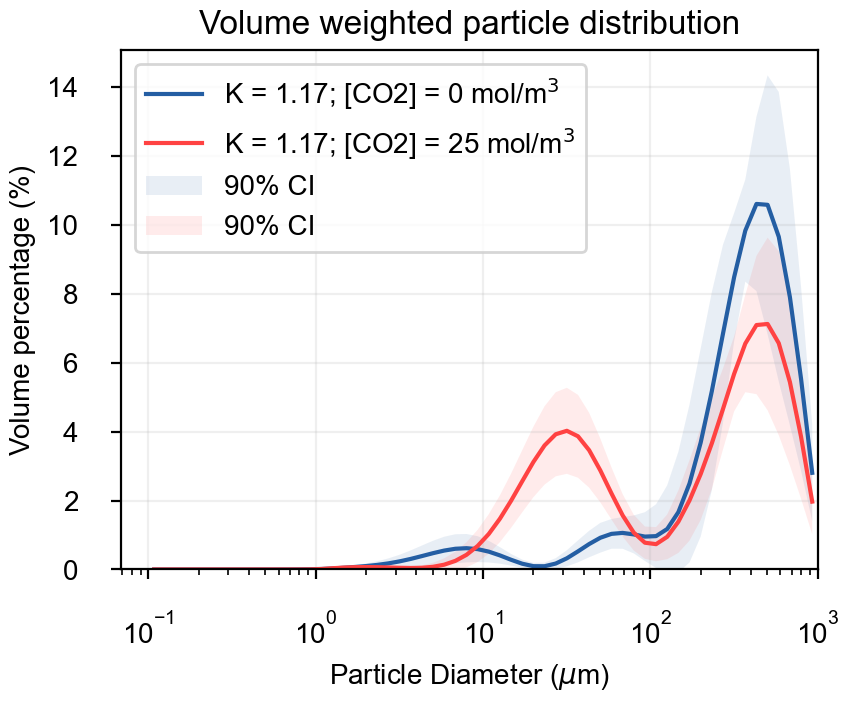

In [51]:
# Volume distribution plot

zzz = 1.65 # 90%CI normally distributed.

plt_col1 = (0.14, 0.37, 0.64) # degassed
plt_col4 = (1, 0.26, 0.26) # dissolved gas

fig, ax = plt.subplots(figsize=(3.37*1.333,3.37))

s = df_run1_v.columns[16:]
run1_v_mean = df_run1_v.iloc[run1_v_start:run1_v_end,16:].mean(axis=0)
run4_v_mean = df_run4_v.iloc[run4_v_start:run4_v_end,16:].mean(axis=0)
run1_v_ci = zzz*df_run1_v.iloc[run1_v_start:run1_v_end,16:].std(axis=0)
run4_v_ci = zzz*df_run4_v.iloc[run1_v_start:run4_v_end,16:].std(axis=0)

ax.plot(s,run1_v_mean, label=r'K = 1.17; [CO2] = 0 mol/m$^3$',c=plt_col1)
ax.plot(s,run4_v_mean, label=r'K = 1.17; [CO2] = 25 mol/m$^3$',c=plt_col4)

ax.fill_between(list(s), list(run1_v_mean-run1_v_ci), list(run1_v_mean+run1_v_ci), fc=plt_col1, alpha=.1, label='90% CI')
ax.fill_between(list(s), list(run4_v_mean-run4_v_ci), list(run4_v_mean+run4_v_ci), fc=plt_col4, alpha=.1, label='90% CI')

'''
ax.errorbar(df_run1_v.columns[16:], df_run1_v.iloc[run1_v_start:run1_v_end,16:].mean(axis=0),\
                           yerr=zzz*df_run1_v.iloc[run1_v_start:run1_v_end,16:].std(axis=0),\
                           capsize=3, label='K = 1.17; [CO2] = 0 M', ls='None', c='k')
ax.errorbar(df_run4_v.columns[16:], df_run4_v.iloc[run4_v_start:run4_v_end,16:].mean(axis=0),\
                           yerr=zzz*df_run4_v.iloc[run4_v_start:run4_v_end,16:].std(axis=0),\
                           capsize=3, label='K = 1.17; [CO2] = 25 M', ls='None', c='r')
'''
ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlim(None,1e3)
ax.set_ylim(0,None)
ax.set_title('Volume weighted particle distribution')

ax.legend(fontsize=10)
plt.grid(alpha=.2)

ax.set_xlabel(r'Particle Diameter ($\mu$m)')
ax.set_ylabel(r'Volume percentage (%)')


plt.savefig('/Users/dduke/Desktop/volume_weighted_size_distr.pdf');

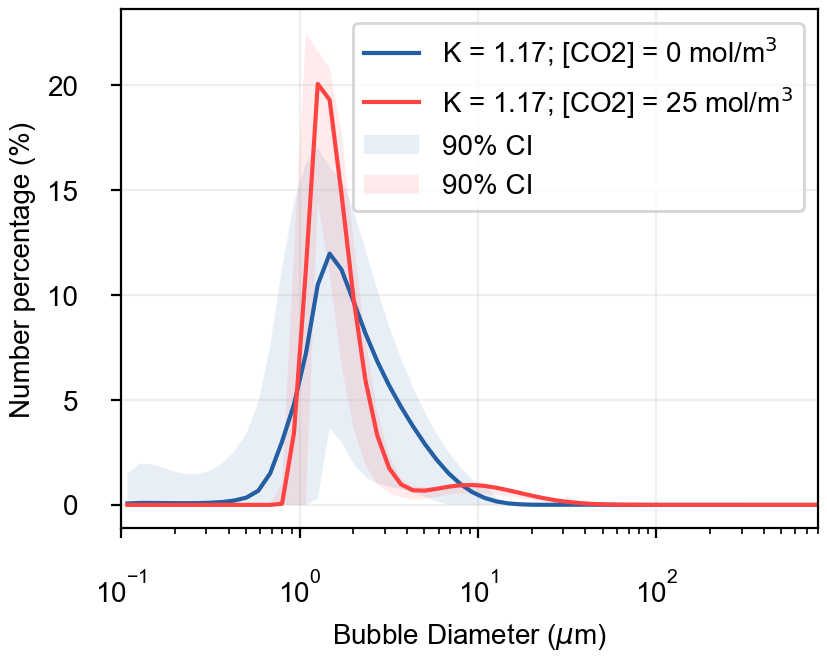

In [96]:
# Number distribution plot

plt_col1 = (0.14, 0.37, 0.64) # degassed
plt_col4 = (1, 0.26, 0.26) # dissolved gas

y_avg1 = df_run1_n.iloc[run1_n_start:run1_n_end,16:].mean(axis=0).to_numpy()
ypos_err1 = 2*df_run1_n.iloc[run1_n_start:run1_n_end,16:].std(axis=0).to_numpy()
yneg_err1 = 2*df_run1_n.iloc[run1_n_start:run1_n_end,16:].std(axis=0).to_numpy()
yneg_err1[ypos_err1 > y_avg1] = y_avg1[ypos_err1 > y_avg1]
y_err1_asym = np.array([yneg_err1, ypos_err1])

y_avg4 = df_run4_n.iloc[run4_n_start:run4_n_end,16:].mean(axis=0).to_numpy()
ypos_err4 = 2*df_run4_n.iloc[run4_n_start:run4_n_end,16:].std(axis=0).to_numpy()
yneg_err4 = 2*df_run4_n.iloc[run4_n_start:run4_n_end,16:].std(axis=0).to_numpy()
yneg_err4[ypos_err4 > y_avg4] = y_avg4[ypos_err4 > y_avg4]
y_err4_asym = np.array([yneg_err4, ypos_err4])

# count = 0
# for i, err in enumerate(yneg_err1):
#     if yneg_err1[i] > y_avg1[i]:
#         yneg_err1[i] = y_avg1[i]
#         count += 1      
# print(f"gotcha {count}")




# yneg_err1 = np.minimum(yneg_err1, y_avg1)





zzz = 1.65/2. # 90%CI normally distributed.
s1 = df_run1_n.columns[16:]
s4 = df_run4_n.columns[16:]
fig, ax = plt.subplots(figsize=(3.37*1.333,3.37))

ax.plot(s1,y_avg1,c=plt_col1, label='K = 1.17; [CO2] = 0 mol/m$^3$')
ax.plot(s4,y_avg4,c=plt_col4, label='K = 1.17; [CO2] = 25 mol/m$^3$')

ypos_err4[16]*=2.5

ax.fill_between(s1.astype(float),zzz*(y_avg1-yneg_err1).astype(float),zzz*(y_avg1+ypos_err1).astype(float),label='90% CI',alpha=.1,fc=plt_col1)
ax.fill_between(s4.astype(float),zzz*(y_avg4-yneg_err4).astype(float),zzz*(y_avg4+ypos_err4).astype(float),label='90% CI',alpha=.1,fc=plt_col4)

#ax.errorbar(s1, y_avg1, yerr=y_err1_asym, capsize=3, label='K = 1.17; [CO2] = 0 mol/m$^3$', color=plt_col1)
#ax.errorbar(s4, y_avg4, yerr=y_err4_asym, capsize=3, label='K = 1.17; [CO2] = 25 mol/m$^3$', color=plt_col4)

ax.set_xscale('log')

ax.set_xlim(0.1, 800)
#ax.set_ylim(0, None)

#ax.legend(loc='upper left', bbox_to_anchor=(-0.2, 1.35), frameon=True, ncol=1);
ax.legend(fontsize=10)
plt.grid(alpha=.2)

# ax.set_title('Number weighted particle distribution')


ax.set_xlabel(r'Bubble Diameter ($\mu$m)')
ax.set_ylabel('Number percentage (%)')

plt.savefig('/Users/dduke/Desktop/num_size_distr.pdf');
plt.show()
# plt.close('all')

#### Number density calculation continued

$$
-ln(T) = N \cdot \int_{0}^{\infty} n(D) ~\sigma(D) ~\,dD\cdot L
$$



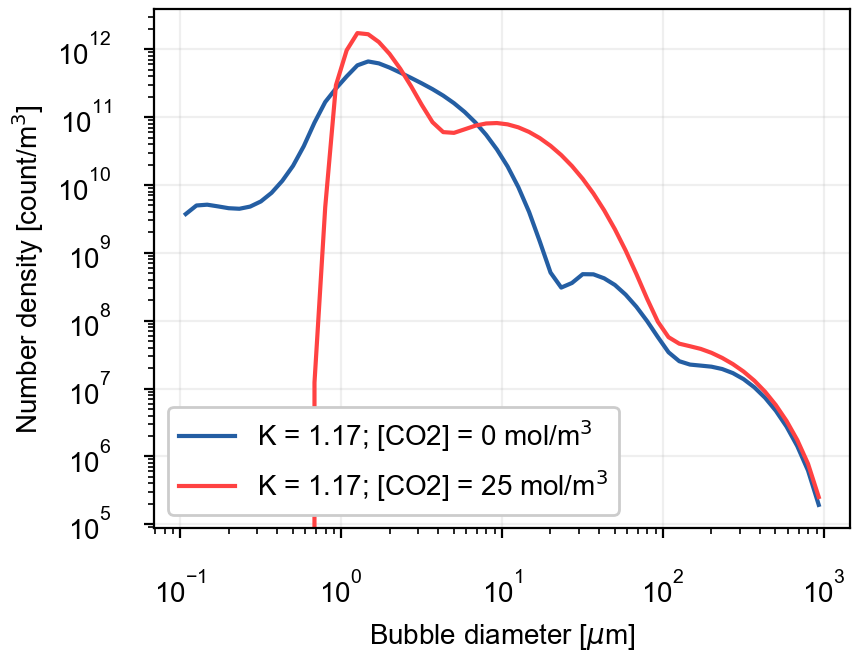

In [103]:
df_run1_n_mean = df_run1_n.iloc[run1_n_start:run1_n_end,16:].mean(axis=0) # mean number density distribution
df_run1_v_mean = df_run1_v.iloc[run1_v_start:run1_v_end,16:].mean(axis=0) # mean volume density distribution
run1_transm_mean = df_run1_n.loc[run1_n_start:run1_n_end,"Transmission"].mean(axis=0) # mean transmission
run1_inst_ext_area = df_run1_n_mean  * sigext # mean extinction area
diam_bin_mid = df_run1_v.columns[start_idx:]

df_run4_n_mean = df_run4_n.iloc[run4_n_start:run4_n_end,16:].mean(axis=0) # mean number density distribution
df_run4_v_mean = df_run4_v.iloc[run4_v_start:run4_v_end,16:].mean(axis=0) # mean volume density distribution
run4_transm_mean = df_run4_n.loc[run4_n_start:run4_n_end,"Transmission"].mean(axis=0) # mean transmission
run4_inst_ext_area = df_run4_n_mean  * sigext # mean extinction area
diam_bin_mid = df_run4_v.columns[start_idx:]

#prop_depths = np.arange(nz_d*0.5, nz_d*4, 0.1) * 0.001 # m, testing propagation depths
prop_depths = np.array([nz_d*2]) * 0.001 # m, testing propagation depths
#prop_depths=np.linspace(nz_d*0.5, nz_d*4,len(run1_inst_ext_area))

num_densitys_run1 = -np.log(run1_transm_mean * 0.01) / (run1_inst_ext_area.sum() * prop_depths) # /m**3
num_densitys_run4 = -np.log(run4_transm_mean * 0.01) / (run4_inst_ext_area.sum() * prop_depths) # /m**3


#fig, ax = plt.subplots()
## Calculate the number density
#ax.plot(prop_depths * 1000, num_densitys_run1)
#ax.set_ylabel('Number density [count/m$^3$]')
#ax.set_xlabel('Laser propagation length [mm]')
#plt.show()
## plt.close('all')

fig, ax = plt.subplots(figsize=(3.37*1.333,3.37))
# Calculate the number density
ax.plot(diam_bin_mid, num_densitys_run1*df_run1_n_mean, label=r'K = 1.17; [CO2] = 0 mol/m$^3$', c= plt_col1)
ax.plot(diam_bin_mid, num_densitys_run4*df_run4_n_mean, label=r'K = 1.17; [CO2] = 25 mol/m$^3$', c= plt_col4)
ax.set_xlabel(r'Bubble diameter [$\mu$m]')
# ax.plot(diam_bin_mid*0.001/nz_d, num_densitys_run1*df_run1_n_mean, label='K = 1.17; [CO2] = 0 M')
# ax.plot(diam_bin_mid*0.001/nz_d, num_densitys_run4*df_run4_n_mean, label='K = 1.17; [CO2] = 25 M')
# ax.set_xlabel('Bubble diameter / D$_{nozzle}$ [-]')
ax.legend(loc='lower left',fontsize=10,framealpha=1)

plt.grid(alpha=.2)


ax.set_ylabel(r'Number density [count/m$^3$]')
ax.set_xscale('log')
#ax.set_xlim(0, 0.01)
ax.set_yscale('log')

plt.savefig('/Users/dduke/Desktop/num_dens_logplot.pdf');

plt.show()
# plt.close('all')



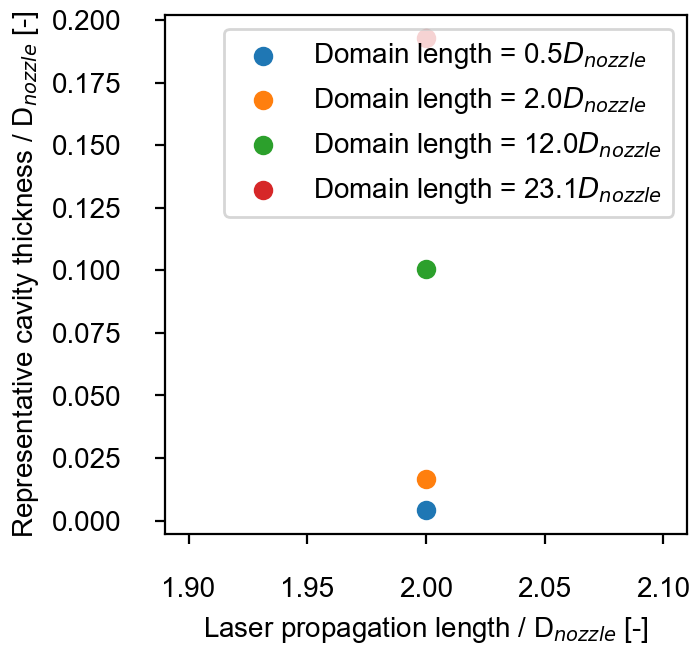

In [106]:
# Varying domain length to see effect on representative thickness of cavity

# domain_lengths = np.array([nz_d * 0.5, nz_d * 2, 0.5*(nz_d+ liq_dom_l), liq_dom_l], dtype=float) * 0.001

# num_abs = num_densitys_run1 * nz_d * 2 * 0.001 * np.pi * (opt_wind_d * 0.001)**2 * 0.25 # Absolute/total number of bubbles - This feels like a dodgy calculation because I have picked a number out of nowhere (similar to the L variable)

# num_abs_dists = np.outer(num_abs, df_run1_n_mean)
# vol_abs_dists = np.tile( np.pi * (1/6) * (diam_bin_mid * 10**-6)**3, [num_abs.shape[0],1])
        
# vol_total = np.sum(num_abs_dists * vol_abs_dists, axis=1)

# rep_cav_thks = vol_total / (np.pi * nz_d * 0.001 * opt_wind_d * 0.001)

domain_lengths = np.array([nz_d * 0.5, nz_d * 2, 0.5*(nz_d+ liq_dom_l), liq_dom_l], dtype=float) * 0.001
fig, ax = plt.subplots()
for i in domain_lengths:
    num_abs = num_densitys_run4 * i * np.pi * (opt_wind_d * 0.001)**2 * 0.25 # Varying domain length to get an idea of its influence
    num_abs_dists = np.outer(num_abs, df_run4_n_mean)
    vol_abs_dists = np.tile( np.pi * (1/6) * (df_run4_v.columns[start_idx:] * 10**-6)**3, [num_abs.shape[0],1])          
    vol_total = np.sum(num_abs_dists * vol_abs_dists, axis=1)
    rep_cav_thks = vol_total / (np.pi * nz_d * 0.001 * opt_wind_d * 0.001)
    # Calculate the total number of bubbles
    # ax.plot(prop_depths * 1000 / nz_d, num_abs, label=f"Domain length = {i*1000/nz_d:.1f}$D_{{nozzle}}$")
    # ax.set_ylabel('Total number of bubbles [count]')
    # Calculate the total volume for different propagation lengths
    # ax.plot(prop_depths * 1000 / nz_d, vol_total, label=f"Domain length = {i*1000/nz_d:.1f}$D_{{nozzle}}$")
    # ax.set_ylabel('Cumulative bubble volume [m$^3$]')
    # Calculate thickness of cavity 
    ax.scatter(prop_depths * 1000 / nz_d, rep_cav_thks * 1000 / nz_d, label=f"Domain length = {i*1000/nz_d:.1f}$D_{{nozzle}}$")
    ax.set_ylabel('Representative cavity thickness / D$_{nozzle}$ [-]')



ax.legend(loc='upper right',fontsize=10)
ax.set_xlabel('Laser propagation length / D$_{nozzle}$ [-]')
plt.show()
# plt.close('all')

In [23]:
# Statistics

# fig, ax = plt.subplots()

# # ax.errorbar(df_run1_v.loc[run1_v_start:run1_v_end,"Time (relative)"], df_run1_v.loc[run1_v_start:run1_v_end,"D[3][2](Value)"], label='K = 1.17; [CO2] = 0 M')
# # ax.errorbar(df_run4_v.loc[run4_v_start:run4_v_end,"Time (relative)"], df_run4_v.loc[run4_v_start:run4_v_end,"D[3][2](Value)"], label='K = 1.17; [CO2] = 25 M')
# # ax.set_ylabel('Sauter Mean Diameter [$\mu$m]')

# ax.errorbar(df_run1_v.loc[run1_v_start:run1_v_end,"Time (relative)"], df_run1_n.loc[run1_v_start:run1_v_end,"Dn(50)(Value)"], label='K = 1.17; [CO2] = 0 M')
# ax.errorbar(df_run4_v.loc[run4_v_start:run4_v_end,"Time (relative)"], df_run4_n.loc[run4_v_start:run4_v_end,"Dn(50)(Value)"], label='K = 1.17; [CO2] = 25 M')
# ax.set_ylabel('Dn(50)(Value) [$\mu$m]')

# # ax.set_ylim(0, 10)
# ax.legend()
# ax.set_title('Particle diameter derived statistics')
# # ax.set_xlim(6, 6.1)

# ax.set_xlabel('Time [s]]')

# df_run1_n.loc[run1_n_start:run1_n_end, "Dn(50)(Value)"].mean(axis=0)
# df_run4_n.loc[run4_n_start:run4_n_end, "Dn(50)(Value)"].mean(axis=0)
# df_run1_n.columns

# df_run1_v.loc[run1_v_start:run1_v_end, "Dv(50)(Value)"].mean(axis=0)
df_run4_v.loc[run4_v_start:run4_v_end, "Dv(50)(Value)"].mean(axis=0)
# df_run1_v.columns

# plt.show()

np.float64(238.46473059932205)

0.108296    0.0
0.126264    0.0
0.147213    0.0
0.171637    0.0
0.200115    0.0
0.233317    0.0
0.272027    0.0
0.31716     0.0
0.369782    0.0
0.431134    0.0
0.502665    0.0
0.586065    0.0
dtype: float64

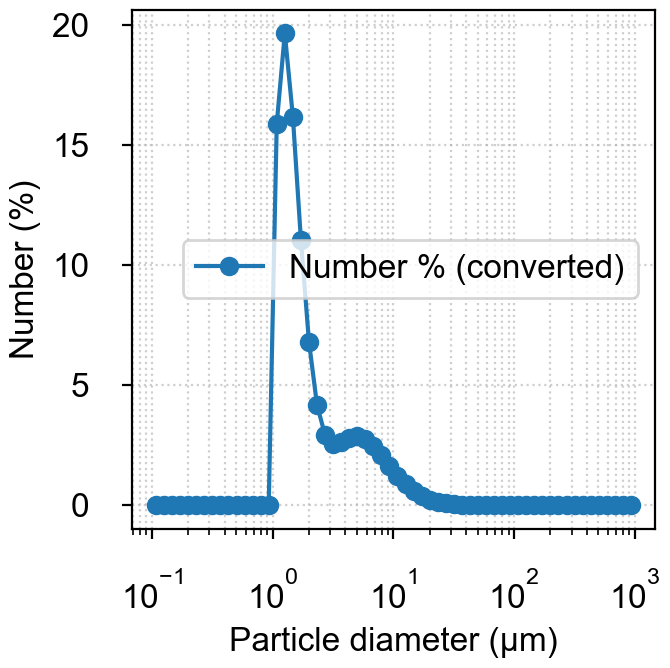

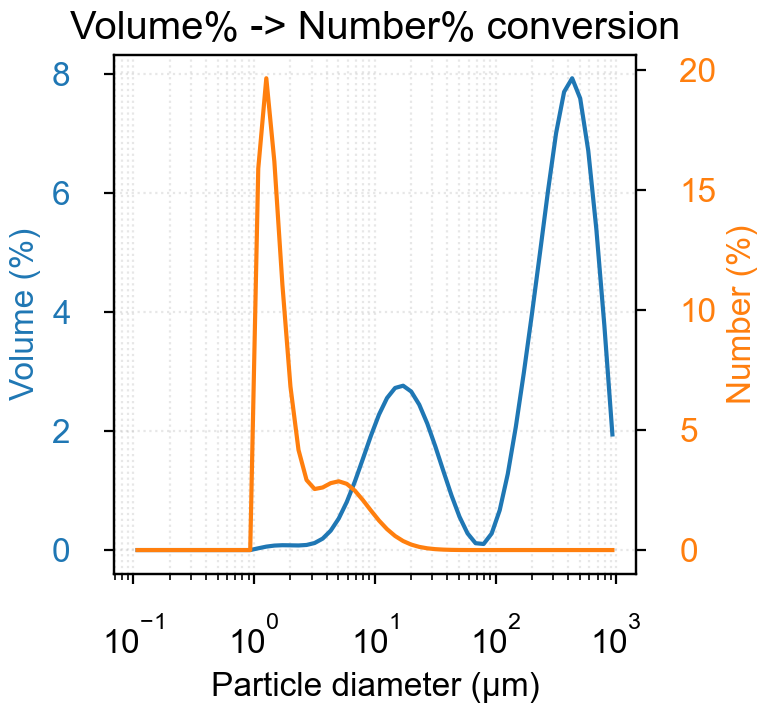

,diameter,volume_percent,number_percent
0,0.108296,0.0,0.0
1,0.126264,0.0,0.0
2,0.147213,0.0,0.0
3,0.171637,0.0,0.0
4,0.200115,0.0,0.0


In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Vectorized conversion: volume% -> number% ---
# Use the same column/row selection you already have in the notebook
diameters = df_run4_v.columns[16:].astype(float).to_numpy()
vol_pct = df_run4_v.iloc[run1_v_start, 16:].astype(float).to_numpy()

# Valid mask (non-NaN diameters and volume entries, positive diameters)
mask_valid = (~np.isnan(vol_pct)) & (~np.isnan(diameters)) & (diameters > 0)
d = diameters[mask_valid]
v_pct = vol_pct[mask_valid].astype(float)

if np.nansum(v_pct) == 0:
    raise ValueError('Selected volume percent row sums to zero or contains no valid data')

# fractions (normalise the selected row to 1)
v_frac = v_pct / np.nansum(v_pct)

# particle volume ∝ d^3 (spherical constant cancels when normalising)
vol_particle = d**3

# number raw (proportional), then normalise to percent
number_raw = v_frac / vol_particle
number_percent = 100.0 * number_raw / np.nansum(number_raw)

# align back to full columns (NaN where invalid)
number_series = pd.Series(index=df_run1_v.columns[16:], dtype=float)
number_series.loc[mask_valid] = number_percent

display(number_series.head(12))

# quick plot of number-percent
fig, ax = plt.subplots()
ax.plot(d, number_percent, marker='o', label='Number % (converted)')
ax.set_xscale('log')
ax.set_xlabel('Particle diameter (μm)')
ax.set_ylabel('Number (%)')
ax.grid(True, which='both', ls=':', alpha=0.6)
ax.legend()
plt.show()

# comparison plot: volume% (left) and number% (right axis)
fig, ax = plt.subplots()
ax.plot(d, v_pct, color='C0', label='Volume %')
ax.set_xscale('log')
ax.set_xlabel('Particle diameter (μm)')
ax.set_ylabel('Volume (%)', color='C0')
ax.tick_params(axis='y', labelcolor='C0')
ax2 = ax.twinx()
ax2.plot(d, number_percent, color='C1', label='Number %')
ax2.set_ylabel('Number (%)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax.grid(True, which='both', ls=':', alpha=0.3)
plt.title('Volume% -> Number% conversion')
plt.show()

# results DataFrame for convenience
results_df = pd.DataFrame({'diameter': d, 'volume_percent': v_pct, 'number_percent': number_percent})
results_df.head()

In [260]:
np.pi * (0.01 ** 2) * 0.25 * 0.035

2.748893571891069e-06

### Estimate absolute particle concentration from transmission and relative distribution

This cell scales the relative number distribution (from `results_df`) to an absolute number concentration using the measured mean transmission in the stable window and the laser path length through the spray.

Assumptions:
- Spherical particles (volume = π/6 d^3).
- Extinction cross-section approximated by Q_ext * geometric cross-section; default Q_ext = 2 (adjustable).
- Transmission T is the fraction (0..1) transmitted through path length L (m).

Outputs:
- `out_df` with per-bin sigma, fraction a_i, concentration per bin (#/m^3) and predicted transmission check.
- `C_tot` (total number concentration #/m^3) and `N_total` (total particles in your supplied domain volume).

mean measured T = 0.7248; path length L = 0.0200 m; Q_ext = 2.0
computed alpha = 1.6092e+01  m^-1
computed total concentration C_tot = 5.5822e+11  #/m^3
predicted transmission from model T_pred = 0.7248 (measured 0.7248)
total particles in domain volume 1.000e-02 m^3: N_total = 5.5822e+09


,diameter,volume_percent,number_percent,a_fraction,sigma_m2,C_i_per_m3,pred_vol_fraction
0,0.108296,0.0,0.0,0.0,1.842231e-14,0.0,0.0
1,0.126264,0.0,0.0,0.0,2.504249e-14,0.0,0.0
2,0.147213,0.0,0.0,0.0,3.404167e-14,0.0,0.0
3,0.171637,0.0,0.0,0.0,4.627476e-14,0.0,0.0
4,0.200115,0.0,0.0,0.0,6.290389e-14,0.0,0.0
5,0.233317,0.0,0.0,0.0,8.550881e-14,0.0,0.0
6,0.272027,0.0,0.0,0.0,1.162369e-13,0.0,0.0
7,0.317160,0.0,0.0,0.0,1.580074e-13,0.0,0.0
8,0.369782,0.0,0.0,0.0,2.147884e-13,0.0,0.0
9,0.431134,0.0,0.0,0.0,2.919740e-13,0.0,0.0


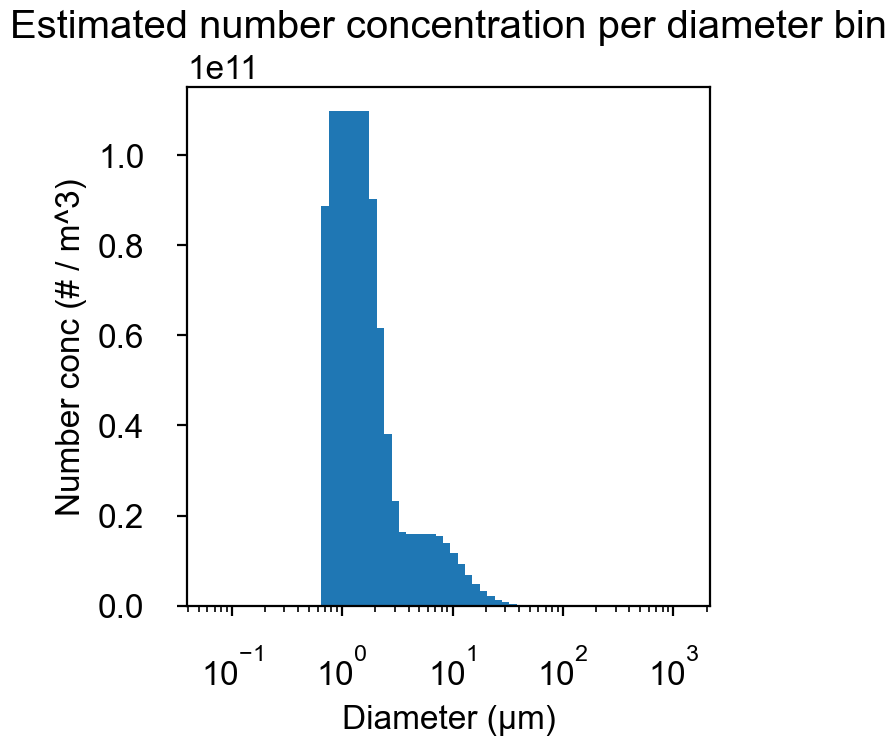

In [68]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

# --- User inputs (tune these) ---
# path length of the laser through the spray (m): set to your instrument path length
path_length_m = 0.02  # example: 20 mm; replace with actual laser path length

# effective extinction efficiency (approx). Use 2.0 as default for large particles;
# replace with Mie-derived Q_ext(d) if available.
Q_ext_scalar = 2.0

# domain volume (m^3) where you want the total particle count reported (your provided value)
domain_volume_m3 = 0.01  # replace with your supplied domain volume

# --- get mean transmission from stable window (use the same run indices you used earlier) ---
trans_series = df_run1_v.loc[run1_v_start:run1_v_end, 'Transmission']
mean_T = np.nanmean(trans_series) / 100.0 if np.nanmax(trans_series) > 1.5 else np.nanmean(trans_series)  # handle percent or fraction
if mean_T <= 0 or mean_T >= 1:
    print('Warning: transmission mean is', mean_T, ' — check units (should be 0..1)')

# --- prepare relative number fractions a_i from your results_df ---
d_um = results_df['diameter'].to_numpy()            # μm
a_raw = results_df['number_percent'].to_numpy()    # % per bin
a = np.nan_to_num(a_raw) / np.nansum(np.nan_to_num(a_raw))  # normalized to sum=1

# convert to meters and compute geometric cross-section
d_m = d_um * 1e-6
geo_cross = np.pi * (d_m / 2.0)**2   # m^2 (geometric area)

# extinction cross-section per bin (use scalar Q_ext or per-bin array if available)
sigma = Q_ext_scalar * geo_cross  # m^2

# compute sum(a_i * sigma_i)
sum_a_sigma = np.nansum(a * sigma)
if sum_a_sigma <= 0 or np.isnan(sum_a_sigma):
    raise ValueError('sum of a*sigma is zero or NaN — check results_df and Q_ext')

# compute extinction coefficient alpha from transmission: alpha = -ln(T)/L
if mean_T <= 0:
    raise ValueError('Mean transmission is <= 0; cannot compute ln(T). Check measurement or masking.')
alpha = -np.log(mean_T) / path_length_m

# total number concentration (sum over bins) in #/m^3
C_tot = alpha / sum_a_sigma

# per-bin concentration (number conc per bin = C_tot * a_i)
C_i = C_tot * a

# predicted transmission check (should match mean_T roughly)
alpha_check = np.nansum(C_i * sigma)
T_pred = np.exp(-alpha_check * path_length_m)

# total particles in user domain volume
N_total = C_tot * domain_volume_m3

# Build output DataFrame
out_df = results_df.copy()
out_df['a_fraction'] = a
out_df['sigma_m2'] = sigma
out_df['C_i_per_m3'] = C_i
out_df['pred_vol_fraction'] = (out_df['C_i_per_m3'] * (np.pi/6.0) * (out_df['diameter']*1e-6)**3) / ((np.nansum(out_df['C_i_per_m3'] * (np.pi/6.0) * (out_df['diameter']*1e-6)**3)) if np.nansum(out_df['C_i_per_m3'] * (np.pi/6.0) * (out_df['diameter']*1e-6)**3) != 0 else 1)

# display results
print(f'mean measured T = {mean_T:.4f}; path length L = {path_length_m:.4f} m; Q_ext = {Q_ext_scalar}')
print(f'computed alpha = {alpha:.4e}  m^-1')
print(f'computed total concentration C_tot = {C_tot:.4e}  #/m^3')
print(f'predicted transmission from model T_pred = {T_pred:.4f} (measured {mean_T:.4f})')
print(f'total particles in domain volume {domain_volume_m3:.3e} m^3: N_total = {N_total:.4e}')
display(out_df.head(12))

# optional plot: concentration per bin
fig, ax = plt.subplots()
ax.bar(d_um, out_df['C_i_per_m3'], width=d_um*0.8, align='center')
ax.set_xscale('log')
ax.set_xlabel('Diameter (μm)')
ax.set_ylabel('Number conc (# / m^3)')
ax.set_title('Estimated number concentration per diameter bin')
plt.show()